## Importación

In [321]:
!pip install langdetect

In [322]:
import pandas as pd
from langdetect import detect

import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk.tag import pos_tag
from nltk.probability import FreqDist

import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [323]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("names")
nltk.download("wordnet")
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('tagsets')
nltk.download('tagsets_json')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package names to /root/nltk_data...
[nltk_data]   Package names is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!
[nltk_data] Downloading package tagsets_json 

True

In [324]:
STOPWORDS = nltk.corpus.stopwords.words("english")
NAMES = nltk.corpus.names.words()

## Análisis Exploratorio de la Data (EDA)

In [ ]:
df = pd.read_csv("new_delhi_reviews.csv")
# obtained from https://www.kaggle.com/datasets/arnabchaki/tripadvisor-reviews-2023

In [326]:
df

,rating_review,review_full
0,5,"Totally in love with the Auro of the place, re..."
1,5,I went this bar 8 days regularly with my husba...
2,5,We were few friends and was a birthday celebra...
3,5,Fatjar Cafe and Market is the perfect place fo...
4,5,"Hey Guys, if you are craving for pizza and sea..."
...,...,...
147576,5,Near by airport very calm and cool environment...
147577,5,My favourite place to stay. Great service. Ash...
147578,5,"good food with nice decoration, drinks list al..."
147579,4,Near to airport .it is fine property. Staff i...


In [327]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147581 entries, 0 to 147580
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   rating_review  147581 non-null  int64 
 1   review_full    147579 non-null  object
dtypes: int64(1), object(1)
memory usage: 2.3+ MB


In [328]:
df["review_full"] = df["review_full"].astype(str)

In [329]:
df.iloc[0]["review_full"]

"Totally in love with the Auro of the place, really beautiful and quite fancy at the same time. The ambience is very pure and gives a sense of positivity throughout. Outdoor and indoor interior are quite quaint and cute. Love the open kitchen idea and there whole marketplace ideology. Due to coronovirus they specifically use disposable cutlery to keep the pandemic in mind taking all the precautionary measures from the beginning of the place with the mask on their staff and using good sanitisation. The food is really amazing specially the pizza straight from the oven and the hummus and pita bread are quite delicious too. If you're looking for a classy yet soothing Italian place in Delhi,Fatjar is a go to for you!"

<Axes: xlabel='rating_review'>

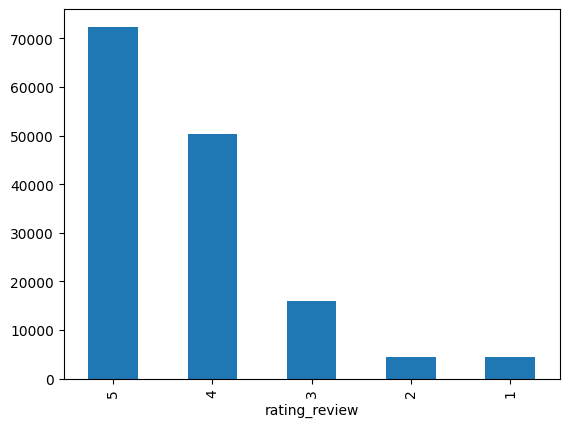

In [330]:
df["rating_review"].value_counts().plot(kind="bar")

In [331]:
df["sentiment"] = df["rating_review"].apply(lambda x: "positive" if x >= 3 else "negative")
df

,rating_review,review_full,sentiment
0,5,"Totally in love with the Auro of the place, re...",positive
1,5,I went this bar 8 days regularly with my husba...,positive
2,5,We were few friends and was a birthday celebra...,positive
3,5,Fatjar Cafe and Market is the perfect place fo...,positive
4,5,"Hey Guys, if you are craving for pizza and sea...",positive
...,...,...,...
147576,5,Near by airport very calm and cool environment...,positive
147577,5,My favourite place to stay. Great service. Ash...,positive
147578,5,"good food with nice decoration, drinks list al...",positive
147579,4,Near to airport .it is fine property. Staff i...,positive


<Axes: xlabel='sentiment'>

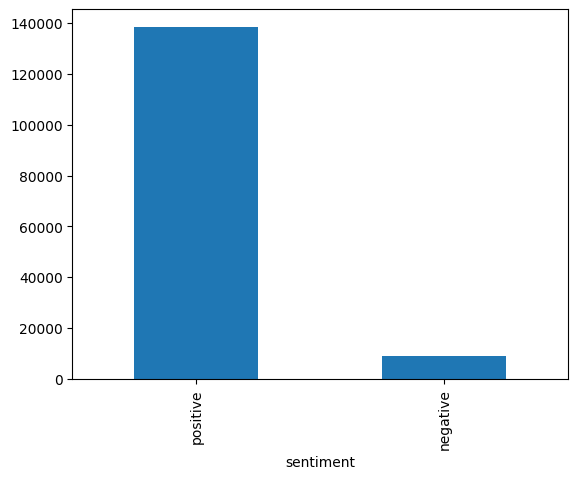

In [332]:
df["sentiment"].value_counts().plot(kind="bar")

In [333]:
df["sentiment"].value_counts()

,count
sentiment,
positive,138574
negative,9007


In [334]:
df["sentiment"].value_counts(normalize=True)

,proportion
sentiment,
positive,0.938969
negative,0.061031


### Balanceo de target

In [335]:
# Tecnicas de balanceo de etiqueta
# Undersampling
# Oversampling
# Hibrido

# En este caso aplicaremos undersampling
min_size_of_target_class = df["sentiment"].value_counts().min()

df = pd.concat([
    df[df["sentiment"] == target].sample(min_size_of_target_class) for target in df["sentiment"].unique()
])

df

,rating_review,review_full,sentiment
40392,3,Our friends told us about Tonino Italian Resta...,positive
74051,5,"If you like Mughlai food, do not waste time an...",positive
18847,5,"Bukhara is literally finger licking good, beca...",positive
79260,3,Nice place for a winter lunch. It was close to...,positive
7946,5,This my first time in HRC Delhi...had couple o...,positive
...,...,...,...
71307,1,Used to be a great place to dine - was great v...,negative
110283,1,We had visited this place on OCT 10 for a Duss...,negative
41467,2,Highly overrated....,negative
138459,2,Had booked the place for my daughter’s birthda...,negative


In [336]:
df["language"] = df["review_full"].apply(lambda x: detect(x))
df

,rating_review,review_full,sentiment,language
40392,3,Our friends told us about Tonino Italian Resta...,positive,en
74051,5,"If you like Mughlai food, do not waste time an...",positive,en
18847,5,"Bukhara is literally finger licking good, beca...",positive,en
79260,3,Nice place for a winter lunch. It was close to...,positive,en
7946,5,This my first time in HRC Delhi...had couple o...,positive,en
...,...,...,...,...
71307,1,Used to be a great place to dine - was great v...,negative,en
110283,1,We had visited this place on OCT 10 for a Duss...,negative,en
41467,2,Highly overrated....,negative,en
138459,2,Had booked the place for my daughter’s birthda...,negative,en


In [337]:
df["language"].value_counts()

,count
language,
en,18008
id,1
nl,1
so,1
ko,1
vi,1
ja,1


In [338]:
# Identificando filas a eliminar
df[df["language"] != "en"]

,rating_review,review_full,sentiment,language
102907,5,i like india gate and kutub minar lotus temple...,positive,id
89331,5,Can't express it in words.......chicken change...,positive,nl
42539,4,Good Aloo Paratha ! Mega size ! Dal was SPICCC...,positive,so
90950,1,"when we eating, roach come out on table. the s...",negative,ko
32703,1,#NAME?,negative,vi
115521,2,はっきり言って、ここはレストランというよりは、ファーストフード店ですね。お手洗い、トイレット...,negative,ja


In [339]:
df = df[df["language"] == "en"]
df

,rating_review,review_full,sentiment,language
40392,3,Our friends told us about Tonino Italian Resta...,positive,en
74051,5,"If you like Mughlai food, do not waste time an...",positive,en
18847,5,"Bukhara is literally finger licking good, beca...",positive,en
79260,3,Nice place for a winter lunch. It was close to...,positive,en
7946,5,This my first time in HRC Delhi...had couple o...,positive,en
...,...,...,...,...
71307,1,Used to be a great place to dine - was great v...,negative,en
110283,1,We had visited this place on OCT 10 for a Duss...,negative,en
41467,2,Highly overrated....,negative,en
138459,2,Had booked the place for my daughter’s birthda...,negative,en


In [340]:
df["prompt_length"] = df["review_full"].apply(lambda x: len(x))
df

/tmp/ipython-input-2738461824.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["prompt_length"] = df["review_full"].apply(lambda x: len(x))


,rating_review,review_full,sentiment,language,prompt_length
40392,3,Our friends told us about Tonino Italian Resta...,positive,en,1163
74051,5,"If you like Mughlai food, do not waste time an...",positive,en,366
18847,5,"Bukhara is literally finger licking good, beca...",positive,en,1282
79260,3,Nice place for a winter lunch. It was close to...,positive,en,366
7946,5,This my first time in HRC Delhi...had couple o...,positive,en,259
...,...,...,...,...,...
71307,1,Used to be a great place to dine - was great v...,negative,en,503
110283,1,We had visited this place on OCT 10 for a Duss...,negative,en,1036
41467,2,Highly overrated....,negative,en,20
138459,2,Had booked the place for my daughter’s birthda...,negative,en,575


<Axes: >

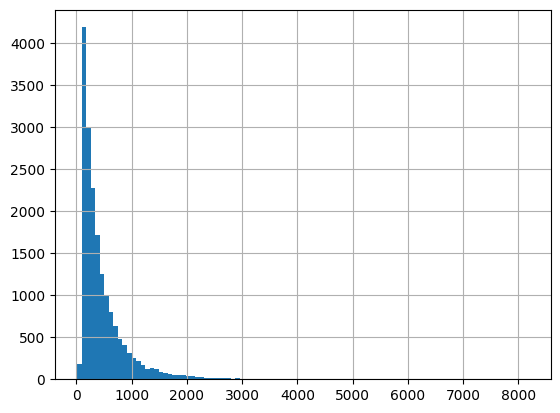

In [341]:
df["prompt_length"].hist(bins=100)

In [342]:
# Revisando los outliers en terminos de tamaño
df[df["prompt_length"] > 1000]
#df.loc[28014]["review_full"]

,rating_review,review_full,sentiment,language,prompt_length
40392,3,Our friends told us about Tonino Italian Resta...,positive,en,1163
18847,5,"Bukhara is literally finger licking good, beca...",positive,en,1282
63581,5,Lanterns is the great alternative to CP bars f...,positive,en,1360
73561,5,|1 Oak| I had heard about the place from a lot...,positive,en,2097
1199,4,NYC offers a fine dining experience by 24/7 an...,positive,en,3279
...,...,...,...,...,...
23467,2,"It was a pre-bday bash of my wife, had few opt...",negative,en,1206
138121,1,So apparently when you spend your money in thi...,negative,en,1798
51017,2,i had visited the restaurant with a colleague ...,negative,en,1125
51013,2,In a giant rat race of the cuisines and buffet...,negative,en,1555


In [343]:
# Revisando los outliers en terminos de tamaño
df[df["prompt_length"] < 25]
#df.loc[41467]["review_full"]

,rating_review,review_full,sentiment,language,prompt_length
41467,2,Highly overrated....,negative,en,20


In [344]:
df = df[df["prompt_length"] > 20]
df

,rating_review,review_full,sentiment,language,prompt_length
40392,3,Our friends told us about Tonino Italian Resta...,positive,en,1163
74051,5,"If you like Mughlai food, do not waste time an...",positive,en,366
18847,5,"Bukhara is literally finger licking good, beca...",positive,en,1282
79260,3,Nice place for a winter lunch. It was close to...,positive,en,366
7946,5,This my first time in HRC Delhi...had couple o...,positive,en,259
...,...,...,...,...,...
62668,1,"They dont know how to make Dosa, sambhar, Dahi...",negative,en,519
71307,1,Used to be a great place to dine - was great v...,negative,en,503
110283,1,We had visited this place on OCT 10 for a Duss...,negative,en,1036
138459,2,Had booked the place for my daughter’s birthda...,negative,en,575


## Preprocesamiento de texto

In [345]:
df.iloc[0]["review_full"]

"Our friends told us about Tonino Italian Restaurant on Mehrauli-Gurgaon Road in Delhi and said it offers a traditional and authentic dining experience. I can't say that I agree with their views! No doubt, the location is great and entire restaurant is exceptionally laid out with the décor being sublime and contemporary. Both the inside and outside seating areas are lovely and welcoming and makes for a wonderful ambience in the evenings. The staff, too, is wonderfully competent, but the food disappointed us. We orders Pizzas, Lasagne and Pasta - our usual affair; but the quality was not very good. The penne in whit sauce was too bland and the pizzas were a little undercooked. Only the vegetarian Lasagne was noteworthy. Now let's come to the price, which perhaps is the most important aspect of dining out in Delhi. We weren't too pleased on that front either. The total cost of a meal for 5 adults, including drinks (wine and whisky) was north of Rs.10,000 which was quite pricey compared t

In [346]:
nltk.help.upenn_tagset()

$: dollar
    $ -$ --$ A$ C$ HK$ M$ NZ$ S$ U.S.$ US$
'': closing quotation mark
    ' ''
(: opening parenthesis
    ( [ {
): closing parenthesis
    ) ] }
,: comma
    ,
--: dash
    --
.: sentence terminator
    . ! ?
:: colon or ellipsis
    : ; ...
CC: conjunction, coordinating
    & 'n and both but either et for less minus neither nor or plus so
    therefore times v. versus vs. whether yet
CD: numeral, cardinal
    mid-1890 nine-thirty forty-two one-tenth ten million 0.5 one forty-
    seven 1987 twenty '79 zero two 78-degrees eighty-four IX '60s .025
    fifteen 271,124 dozen quintillion DM2,000 ...
DT: determiner
    all an another any both del each either every half la many much nary
    neither no some such that the them these this those
EX: existential there
    there
FW: foreign word
    gemeinschaft hund ich jeux habeas Haementeria Herr K'ang-si vous
    lutihaw alai je jour objets salutaris fille quibusdam pas trop Monte
    terram fiche oui corporis ...
IN: preposition or

In [347]:
# Stemmer
simplifier = PorterStemmer()
# Lematizador
#simplifier = WordNetLemmatizer()

In [348]:
# Guardar los archivos necesarios para preprocesar texto
with open("model/simplifier.pkl", "wb") as f:
  pickle.dump(simplifier, f)

In [349]:
def get_tokens(review, simplifier_func=None):

  tokens = word_tokenize(review)
  cleaned_tokens = []
  for token in tokens:
    if not token.isalpha(): continue
    if token in NAMES: continue
    token = token.lower()
    if token in STOPWORDS: continue
    if pos_tag([token])[0][1][:2] not in ["NN", "VB", "JJ", "RB"]: continue
    if simplifier_func: token = simplifier_func(token)
    cleaned_tokens.append(token)

  return cleaned_tokens

In [350]:
df.iloc[0]["review_full"]

"Our friends told us about Tonino Italian Restaurant on Mehrauli-Gurgaon Road in Delhi and said it offers a traditional and authentic dining experience. I can't say that I agree with their views! No doubt, the location is great and entire restaurant is exceptionally laid out with the décor being sublime and contemporary. Both the inside and outside seating areas are lovely and welcoming and makes for a wonderful ambience in the evenings. The staff, too, is wonderfully competent, but the food disappointed us. We orders Pizzas, Lasagne and Pasta - our usual affair; but the quality was not very good. The penne in whit sauce was too bland and the pizzas were a little undercooked. Only the vegetarian Lasagne was noteworthy. Now let's come to the price, which perhaps is the most important aspect of dining out in Delhi. We weren't too pleased on that front either. The total cost of a meal for 5 adults, including drinks (wine and whisky) was north of Rs.10,000 which was quite pricey compared t

In [351]:
get_tokens(df.iloc[0]["review_full"], simplifier.stem)

['friend',
 'told',
 'tonino',
 'italian',
 'restaur',
 'road',
 'delhi',
 'said',
 'offer',
 'tradit',
 'authent',
 'dine',
 'experi',
 'say',
 'agre',
 'view',
 'doubt',
 'locat',
 'great',
 'entir',
 'restaur',
 'except',
 'laid',
 'décor',
 'sublim',
 'contemporari',
 'seat',
 'area',
 'love',
 'welcom',
 'make',
 'wonder',
 'ambienc',
 'even',
 'staff',
 'wonder',
 'compet',
 'food',
 'disappoint',
 'order',
 'pizza',
 'lasagn',
 'pasta',
 'usual',
 'affair',
 'qualiti',
 'good',
 'penn',
 'whit',
 'sauc',
 'bland',
 'pizza',
 'littl',
 'undercook',
 'vegetarian',
 'lasagn',
 'noteworthi',
 'let',
 'come',
 'price',
 'perhap',
 'import',
 'aspect',
 'dine',
 'delhi',
 'pleas',
 'front',
 'total',
 'cost',
 'meal',
 'adult',
 'includ',
 'drink',
 'wine',
 'whiski',
 'north',
 'quit',
 'pricey',
 'compar',
 'qualiti',
 'food',
 'serv',
 'summari',
 'tonino',
 'restaur',
 'delhi',
 'great',
 'locat',
 'ambienc',
 'food',
 'averag',
 'extrem',
 'pricey']

In [352]:
df["tokens"] = df["review_full"].apply(lambda x: get_tokens(x, simplifier_func=simplifier.stem))
df

/tmp/ipython-input-1587881772.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tokens"] = df["review_full"].apply(lambda x: get_tokens(x, simplifier_func=simplifier.stem))


,rating_review,review_full,sentiment,language,prompt_length,tokens
40392,3,Our friends told us about Tonino Italian Resta...,positive,en,1163,"[friend, told, tonino, italian, restaur, road,..."
74051,5,"If you like Mughlai food, do not waste time an...",positive,en,366,"[mughlai, food, wast, time, money, elsewher, s..."
18847,5,"Bukhara is literally finger licking good, beca...",positive,en,1282,"[bukhara, liter, finger, lick, good, way, real..."
79260,3,Nice place for a winter lunch. It was close to...,positive,en,366,"[nice, place, winter, lunch, close, empti, wen..."
7946,5,This my first time in HRC Delhi...had couple o...,positive,en,259,"[first, time, hrc, delhi, coupl, drink, food, ..."
...,...,...,...,...,...,...
62668,1,"They dont know how to make Dosa, sambhar, Dahi...",negative,en,519,"[dont, know, make, dosa, sambhar, dahi, bhalla..."
71307,1,Used to be a great place to dine - was great v...,negative,en,503,"[use, great, place, dine, great, valu, money, ..."
110283,1,We had visited this place on OCT 10 for a Duss...,negative,en,1036,"[visit, place, oct, dussehra, even, famili, di..."
138459,2,Had booked the place for my daughter’s birthda...,negative,en,575,"[book, place, daughter, birthday, arriv, priva..."


## Análisis del vocabulario y selección de features

In [353]:
full_vocabulary = []
vocabulary = {category: [] for category in df["sentiment"].unique()}
for _, row in df.iterrows():
  tokens = row["tokens"]
  sentiment = row["sentiment"]
  vocabulary[sentiment] += tokens
  full_vocabulary += tokens

In [354]:
print(f"Cantidad de tokens del vocabulario: {len(FreqDist(full_vocabulary))}")

Cantidad de tokens del vocabulario: 21630


In [355]:
FreqDist(full_vocabulary).most_common(2000)

[('food', 18009),
 ('place', 12064),
 ('good', 10027),
 ('restaur', 8565),
 ('servic', 7972),
 ('order', 6911),
 ('serv', 5459),
 ('time', 5279),
 ('visit', 5098),
 ('tast', 4995),
 ('chicken', 4624),
 ('staff', 4481),
 ('even', 4085),
 ('go', 4066),
 ('dish', 3867),
 ('great', 3685),
 ('tri', 3675),
 ('also', 3505),
 ('experi', 3465),
 ('tabl', 3328),
 ('get', 3212),
 ('realli', 3187),
 ('delhi', 3149),
 ('menu', 3030),
 ('indian', 2875),
 ('well', 2790),
 ('ask', 2762),
 ('nice', 2715),
 ('price', 2602),
 ('went', 2590),
 ('qualiti', 2573),
 ('drink', 2525),
 ('manag', 2511),
 ('recommend', 2419),
 ('best', 2386),
 ('love', 2296),
 ('look', 2252),
 ('eat', 2227),
 ('ambienc', 2171),
 ('come', 2164),
 ('much', 2124),
 ('friend', 2094),
 ('bad', 2026),
 ('want', 1992),
 ('make', 1990),
 ('wait', 1964),
 ('meal', 1963),
 ('peopl', 1948),
 ('better', 1941),
 ('waiter', 1892),
 ('dinner', 1882),
 ('back', 1864),
 ('first', 1854),
 ('disappoint', 1792),
 ('take', 1768),
 ('came', 1732),
 (

In [356]:
most_common_tokens = set()
for category in df["sentiment"].unique():
  most_common_tokens = most_common_tokens.union(set([token for token, _ in FreqDist(vocabulary[category]).most_common(500)]))
most_common_tokens

{'absolut',
 'accept',
 'accompani',
 'actual',
 'ad',
 'add',
 'almost',
 'alreadi',
 'also',
 'alway',
 'amaz',
 'ambianc',
 'ambienc',
 'amount',
 'anyon',
 'anyth',
 'apolog',
 'appreci',
 'area',
 'arrang',
 'arriv',
 'asian',
 'ask',
 'ate',
 'atmospher',
 'attend',
 'attent',
 'attitud',
 'attract',
 'authent',
 'avail',
 'averag',
 'avoid',
 'aw',
 'away',
 'awesom',
 'back',
 'bad',
 'bar',
 'base',
 'basic',
 'beauti',
 'beer',
 'believ',
 'best',
 'better',
 'big',
 'bill',
 'birthday',
 'biryani',
 'bit',
 'bite',
 'bland',
 'book',
 'bother',
 'bottl',
 'bowl',
 'brand',
 'bread',
 'breakfast',
 'bring',
 'brought',
 'buffet',
 'bukhara',
 'burger',
 'busi',
 'butter',
 'cafe',
 'cake',
 'call',
 'came',
 'card',
 'care',
 'case',
 'celebr',
 'chaat',
 'chang',
 'charg',
 'cheap',
 'check',
 'chees',
 'chef',
 'chicken',
 'chill',
 'chilli',
 'chines',
 'chocol',
 'choic',
 'choos',
 'chutney',
 'citi',
 'clean',
 'close',
 'cocktail',
 'coconut',
 'coffe',
 'cold',
 'comb

In [357]:
print(f"Cantidad de tokens comunes: {len(most_common_tokens)}")

Cantidad de tokens comunes: 622


In [358]:
# Guardar los archivos necesarios para preprocesar texto
with open("model/most_common_tokens.pkl", "wb") as f:
  pickle.dump(most_common_tokens, f)

### Update de la función obtener tokens

In [359]:
def get_tokens_training(review, most_common_tokens, simplifier_func=None):

  tokens = word_tokenize(review)
  cleaned_tokens = []
  for token in tokens:
    if not token.isalpha(): continue
    if token in NAMES: continue
    token = token.lower()
    if token in STOPWORDS: continue
    if pos_tag([token])[0][1][:2] not in ["NN", "VB", "JJ", "RB"]: continue
    if simplifier_func: token = simplifier_func(token)
    if token not in most_common_tokens: continue
    cleaned_tokens.append(token)

  return " ".join(cleaned_tokens)

## Vectorización

In [360]:
get_tokens_training("I like the food, it was excellent", most_common_tokens, simplifier_func=simplifier.stem)

'food excel'

In [361]:
df["token_string"] = df["review_full"].apply(lambda x: get_tokens_training(x, most_common_tokens, simplifier_func=simplifier.stem))
df

/tmp/ipython-input-1278915480.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["token_string"] = df["review_full"].apply(lambda x: get_tokens_training(x, most_common_tokens, simplifier_func=simplifier.stem))


,rating_review,review_full,sentiment,language,prompt_length,tokens,token_string
40392,3,Our friends told us about Tonino Italian Resta...,positive,en,1163,"[friend, told, tonino, italian, restaur, road,...",friend told italian restaur road delhi said of...
74051,5,"If you like Mughlai food, do not waste time an...",positive,en,366,"[mughlai, food, wast, time, money, elsewher, s...",food wast time money head outlet special head ...
18847,5,"Bukhara is literally finger licking good, beca...",positive,en,1282,"[bukhara, liter, finger, lick, good, way, real...",bukhara good way realli enjoy consist visit bu...
79260,3,Nice place for a winter lunch. It was close to...,positive,en,366,"[nice, place, winter, lunch, close, empti, wen...",nice place lunch close empti went park right r...
7946,5,This my first time in HRC Delhi...had couple o...,positive,en,259,"[first, time, hrc, delhi, coupl, drink, food, ...",first time delhi coupl drink food new menu rea...
...,...,...,...,...,...,...,...
62668,1,"They dont know how to make Dosa, sambhar, Dahi...",negative,en,519,"[dont, know, make, dosa, sambhar, dahi, bhalla...",dont know make dosa dahi chaat thing bad tast ...
71307,1,Used to be a great place to dine - was great v...,negative,en,503,"[use, great, place, dine, great, valu, money, ...",use great place dine great valu money realli b...
110283,1,We had visited this place on OCT 10 for a Duss...,negative,en,1036,"[visit, place, oct, dussehra, even, famili, di...",visit place even famili dinner famili first or...
138459,2,Had booked the place for my daughter’s birthda...,negative,en,575,"[book, place, daughter, birthday, arriv, priva...",book place birthday arriv floor dirti make cle...


In [362]:
vectorizer = TfidfVectorizer()
vectorizer.fit(df["token_string"])

TfidfVectorizer()

In [363]:
X = pd.DataFrame(
    vectorizer.transform(df["token_string"]).toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df.index
)
X

,absolut,accept,accompani,actual,ad,add,almost,alreadi,also,alway,...,world,wors,worst,worth,write,wrong,ye,year,yet,yummi
40392,0.00000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
74051,0.00000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.228536,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
18847,0.00000,0.0,0.0,0.0,0.0,0.0,0.183493,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.173012,0.000000,0.0
79260,0.00000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
7946,0.00000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62668,0.00000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
71307,0.00000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
110283,0.11732,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
138459,0.00000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.173659,0.0


In [364]:
with open("model/vectorizer.pkl", "wb") as f:
  pickle.dump(vectorizer, f)

## Entrenamiento del modelo

In [365]:
y = df["sentiment"]
y

,sentiment
40392,positive
74051,positive
18847,positive
79260,positive
7946,positive
...,...
62668,negative
71307,negative
110283,negative
138459,negative


In [366]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [367]:
model = KNeighborsClassifier()
model.fit(X_train, y_train)

KNeighborsClassifier()

In [368]:
result = pd.concat([
    y_test.rename("real"),
    pd.Series(model.predict(X_test), index=y_test.index, name="predicted")
], axis=1)
result

,real,predicted
88264,positive,positive
81119,negative,positive
88893,positive,positive
61784,positive,positive
73367,negative,positive
...,...,...
88183,positive,positive
116851,negative,positive
78848,negative,positive
137477,negative,negative


In [369]:
print(f"El accuracy es: {accuracy_score(result['real'], result['predicted'])}")
print(f"El precision es: {precision_score(result['real'], result['predicted'], pos_label='positive')}")
print(f"El recall es: {recall_score(result['real'], result['predicted'], pos_label='positive')}")
print(f"El f1 es: {f1_score(result['real'], result['predicted'], pos_label='positive')}")

El accuracy es: 0.78317601332593
El precision es: 0.763727959697733
El recall es: 0.8293216630196937
El f1 es: 0.7951744033569368


In [370]:
print(classification_report(result["real"], result["predicted"]))

              precision    recall  f1-score   support

    negative       0.81      0.74      0.77      1774
    positive       0.76      0.83      0.80      1828

    accuracy                           0.78      3602
   macro avg       0.79      0.78      0.78      3602
weighted avg       0.79      0.78      0.78      3602



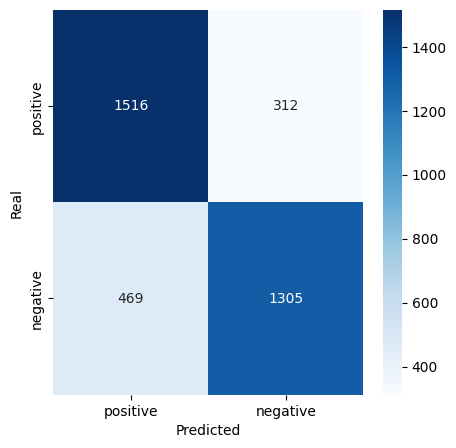

In [371]:
import seaborn as sns
import matplotlib.pyplot as plt
labels = result["real"].unique()
cf = confusion_matrix(result["real"], result["predicted"], labels=labels)
fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cf, annot=True, cmap="Blues", fmt="d", ax=ax, xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Real")
print("")

In [372]:
## Probar con varios modelos
models = [KNeighborsClassifier, RandomForestClassifier, MultinomialNB, LogisticRegression]

for model in models:
  model = model()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print(f"El accuracy del modelo es: {accuracy_score(y_test, y_pred)}")

El accuracy del modelo es: 0.78317601332593
El accuracy del modelo es: 0.8714602998334259
El accuracy del modelo es: 0.8764575235980011
El accuracy del modelo es: 0.8945030538589672


In [373]:
with open("model/model.pkl", "wb") as f:
  pickle.dump(model, f)

## Simulación de espacio productivo

In [ ]:
df_inference = pd.read_csv("new_delhi_reviews.csv").sample(1000)

In [375]:
with open("model/vectorizer.pkl", "rb") as f:
  vectorizer_inference = pickle.load(f)

In [376]:
with open("model/model.pkl", "rb") as f:
  model_inference = pickle.load(f)

In [377]:
with open("model/most_common_tokens.pkl", "rb") as f:
  most_common_tokens_inference = pickle.load(f)

In [378]:
with open("model/simplifier.pkl", "rb") as f:
  simplifier_inference = pickle.load(f)

In [379]:
def get_tokens_inference(review, most_common_tokens, simplifier_func=None):

  tokens = word_tokenize(review)
  cleaned_tokens = []
  for token in tokens:
    if not token.isalpha(): continue
    if token in NAMES: continue
    token = token.lower()
    if token in STOPWORDS: continue
    if pos_tag([token])[0][1][:2] not in ["NN", "VB", "JJ", "RB"]: continue
    if simplifier_func: token = simplifier_func(token)
    if token not in most_common_tokens: continue
    cleaned_tokens.append(token)

  return " ".join(cleaned_tokens)

In [380]:
df_inference["token_string"] = df_inference["review_full"].apply(lambda x: get_tokens_inference(x, most_common_tokens_inference, simplifier_func=simplifier_inference.stem))
X_inference = pd.DataFrame(
    vectorizer_inference.transform(df_inference["token_string"]).toarray(),
    columns=vectorizer_inference.get_feature_names_out(),
    index=df_inference.index
)
y_inference = model_inference.predict(X_inference)

In [381]:
df_inference["prediction"] = y_inference
df_inference[["review_full", "prediction"]]

,review_full,prediction
119508,An outstanding team at the well trusted hotel ...,positive
30648,The new menu is fantastic. Try the salt chicke...,positive
132920,"Ambience is decent, 3.5/5 I saw speakers but t...",positive
51731,A very good Japanese restaurant with great foo...,positive
96983,I would like to thank Mr.Pradeep Uniyal for th...,positive
...,...,...
51399,Called in for lunch and had the chefs special....,positive
123303,Great food and great service always.chef pleas...,positive
12799,Nice colorful place to hang out. Lasagne is cr...,positive
695,"Great ambience of NYC, and specially thanks to...",positive
